# Name : Krishna lund
# Cms-id : 023-24-0271
# Section - H
# Github Profile : https://github.com/Krishnalund/machine-learning-practical-work
# Kaggle Profile : https://www.kaggle.com/krishnalund18
# Dataset : https://www.kaggle.com/datasets/vedatgul/telco-churn-dataset


# Section 1 : Problem Definition & Dataset Verification

In [6]:
# Task-1 Load clean_churn.csv (or re-run your Lab 2 cleaning) and verify its shape and dtypes.

import pandas as pd
df = pd.read_csv("clean_churn.csv")
print("Shape:", df.shape)
df.info()

Shape: (7021, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   str    
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   str    
 3   Dependents        7021 non-null   str    
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   str    
 6   MultipleLines     7021 non-null   str    
 7   InternetService   7021 non-null   str    
 8   OnlineSecurity    7021 non-null   str    
 9   OnlineBackup      7021 non-null   str    
 10  DeviceProtection  7021 non-null   str    
 11  TechSupport       7021 non-null   str    
 12  StreamingTV       7021 non-null   str    
 13  StreamingMovies   7021 non-null   str    
 14  Contract          7021 non-null   str    
 15  PaperlessBilling  7021 non-null   str    
 16  PaymentMethod     7021 non-null   s

**Task-1 Explanation:**
_(In this code, loads the cleaned dataset from lab2 that is clean_churn.csv and find the numbe rof features
and records using df.shape and then check the data types using df.info or dtypes.)_

**Task-2 Briefly restate (2–3 sentences) your Lab 3 Decision Tree and Lab 4 Random Forest test-set results (accuracy,
precision, recall, F1) — these are your benchmarks for today.**

**Explanation:**
_(My Lab 3 Decision Tree (max_depth=5) achieved 78.7% accuracy, 65.1% precision, 42.2% recall, and 51.2% F1-score. 
My Lab 4 tuned Random Forest improved on this with 79.8% accuracy, 66.1% precision, 48.7% recall, and 56.0% F1-score, 
making it my strongest benchmark so far. )_

# Section 2: Feature Scaling & Preparation

In [8]:
# Task-3 Prepare X and y exactly as in Lab 3/4 (encode categoricals, drop identifiers, target as 0/1).

from sklearn.model_selection import train_test_split

y = df["Churn"].map({'No': 0, 'Yes': 1})
X = df.drop(columns=["Churn"])
X = pd.get_dummies(X, drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5616, 30)
X_test shape: (1405, 30)


**Task-3 Explanation:**
_(This code converts Churn into 0/1, separates the target from the features, converts categorical features
into numbers, and then creates an 80/20 stratified train-test split using the same random state=42 as Lab 4.)_

**Task-4 In 2–3 sentences, explain why feature scaling matters for KNN and Logistic Regression but wasn't necessary for
the Decision Tree or Random Forest.**

**Explanation:**
_(Feature scaling is important for KNN because it uses distance, so features with larger values can dominate the calculation.
Logistic Regression also benefits from scaling for faster and more reliable learning, while Decision Trees and Random Forests use 
threshold-based splits, so feature scale does not affect their decisions.)_


In [9]:
# Task-5 Split into train/test (same split strategy as Lab 3/4), then fit a StandardScaler on the training features only and
# apply it to both sets. Why is it important to fit the scaler only on the training data?

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Task-5 Explanation:**
_(We fit the scaler only on training data because the test data should remain completely unseen. 
If we fit the scaler on the full dataset, information such as the test data’s mean and standard deviation 
would leak into the training process (data leakage) , which could make the model’s evaluation look better than it really is.)_

# Section 3 : Logistic Regression

In [10]:
# Task-6 Train a LogisticRegression model on the scaled training data. Generate predictions on the scaled test set.

from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
lr_pred = logreg.predict(X_test_scaled)

**Task-6 Explanation:**
_(The Logistic Regression model is trained using the scaled training features (X_train_scaled) and 
their corresponding Churn labels (y_train).Then, the trained model uses X_test_scaled to predict Churn for the
unseen test data, and the predictions are stored in lr_pred.)_

Logistic Regression — Accuracy: 0.804, Precision: 0.662, Recall: 0.527, F1: 0.587


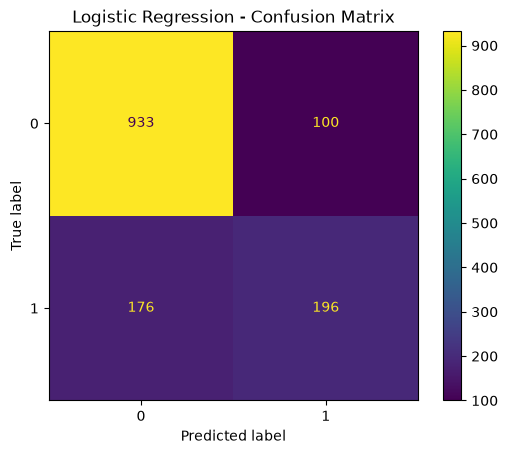

In [11]:
# Task-7  Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

lr_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print(f"Logistic Regression — Accuracy: {lr_acc:.3f}, Precision: {lr_prec:.3f}, Recall: {lr_rec:.3f}, F1: {lr_f1:.3f}")

cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

**Task-7 Explanation:**
_(The Logistic Regression model achieved 80.4% accuracy, 66.2% precision, 52.7% recall, and an F1-score of 0.587.
It correctly identified 196 out of 372 churn customers.
It missed 176 churn customers.
Out of 296 customers predicted to churn, 196 actually churned, giving 66.2% precision.
Overall, the model performs better than the Decision Tree and Random Forest on these test-set metrics.)_

In [12]:
# Task-8 Look at predict_proba for a handful of test customers. In 1–2 sentences, explain what these probabilities
# represent and how predict() turns them into a Yes/No decision.

proba = logreg.predict_proba(X_test_scaled)[:10]
print(proba)

[[0.24108696 0.75891304]
 [0.3852258  0.6147742 ]
 [0.71605066 0.28394934]
 [0.9513982  0.0486018 ]
 [0.99097454 0.00902546]
 [0.67019151 0.32980849]
 [0.84525122 0.15474878]
 [0.20769143 0.79230857]
 [0.98250254 0.01749746]
 [0.98488292 0.01511708]]


In [13]:
print(logreg.predict(X_test_scaled)[:10])

[1 1 0 0 0 0 0 1 0 0]


**Task-8 Explanation:**
_(predict_proba() gives the probability of each customer being in the "No" or "Yes" class. The two probabilities always add up to 1.
predict() uses a 0.5 (50%) threshold:
If P(Yes) ≥ 0.5 → predicts "Yes" (customer will churn)
If P(Yes) < 0.5 → predicts "No" (customer will not churn)
So, customers 1 and 8 have P(Yes) of 0.759 and 0.792, so they are predicted as "Yes", and 
the remaining customers are predicted as "No.")_

# Section 4 : KNN & Choosing K

In [14]:
# Task-9 Train KNN classifiers for several values of K (e.g. 1, 3, 5, 7, 9, 11, 15, 21) on the scaled data. Record test-set
# accuracy and F1-score for each K in a results table.

from sklearn.neighbors import KNeighborsClassifier

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    preds = knn.predict(X_test_scaled)
    results.append({
        'K': k,
        'Accuracy': accuracy_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results)
print(results_df)

    K  Accuracy        F1
0   1  0.718861  0.468371
1   3  0.736655  0.481793
2   5  0.752313  0.500000
3   7  0.771530  0.536797
4   9  0.774377  0.543885
5  11  0.773665  0.544413
6  15  0.784342  0.570213
7  21  0.779359  0.560907


**Task-9 Explanation:**
_(This code trains KNN classifiers with different K values: 1, 3, 5, 7, 9, 11, 15, and 21.
The model is trained on scaled training data.
For each K, it predicts the test data.
Accuracy and F1-score are calculated and stored in a table.
From the results, K = 15 gives the highest accuracy (78.43%) and F1-score (57.02%) among the tested values.)_

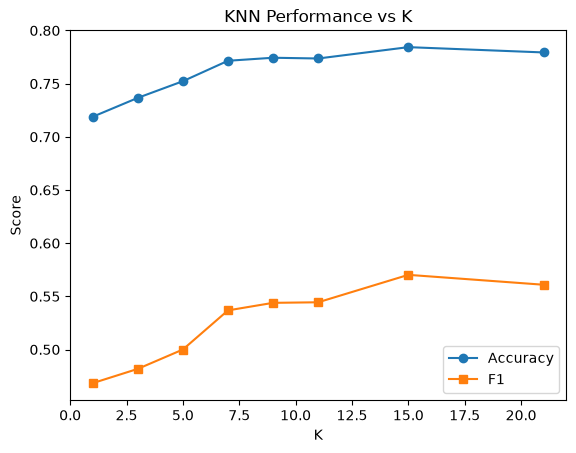

In [16]:
# Task-10  Plot accuracy (or F1) against K. Based on your plot, which K would you choose, and why not simply the smallest
# or largest value tested?

plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['K'], results_df['F1'], marker='s', label='F1')
plt.xlabel('K')
plt.ylabel('Score')
plt.legend()
plt.title('KNN Performance vs K')
plt.show()

**Task-10 Explanation:**
_(I would choose K = 15 because it gives the highest accuracy and F1-score.
K = 1 performs worst because it is too sensitive to noise.
K = 21 performs slightly worse because too many neighbors can reduce useful information.
K = 15 gives a good balance and the best results in this test.)_

0.7843416370106762 0.6036036036036037 0.5403225806451613 0.5702127659574469


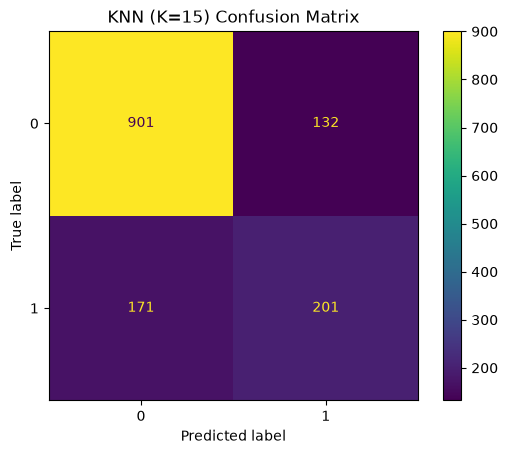

In [17]:
# Task-11 Using your chosen K, report full test-set metrics (accuracy, precision, recall, F1) and the confusion matrix for
# your final KNN model.

best_k = 15  
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)

print(accuracy_score(y_test, y_pred_knn),
      precision_score(y_test, y_pred_knn),
      recall_score(y_test, y_pred_knn),
      f1_score(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn).plot()
plt.title(f"KNN (K={best_k}) Confusion Matrix")
plt.show()

**Task-11 Explanation:**
_(With K = 15, the KNN model gets 78.3% accuracy and an F1-score of 0.570.
It correctly identifies 54% of churn customers.
It misses 46% of actual churn customers.
When it predicts churn, it is correct about 60% of the time.
Accuracy is higher because the model performs better on the majority "No churn" class.)_

# Section 5 : Model Comparison (4 Models)

In [19]:
# Task-12 Build one comparison table: Decision Tree, Random Forest, Logistic Regression, KNN — accuracy, precision,
# recall, F1-score for each (reuse your recorded Lab 3/4 numbers; retrain quickly if needed).

comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Logistic Regression", "KNN"],
    "Accuracy":  [0.787189, 0.797865, lr_acc, accuracy_score(y_test, y_pred_knn)],
    "Precision": [0.651452, 0.660584, lr_prec, precision_score(y_test, y_pred_knn)],
    "Recall":    [0.422043, 0.486559, lr_rec, recall_score(y_test, y_pred_knn)],
    "F1-score":  [0.512235, 0.560372, lr_f1, f1_score(y_test, y_pred_knn)]
})
print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1-score
0        Decision Tree  0.787189   0.651452  0.422043  0.512235
1        Random Forest  0.797865   0.660584  0.486559  0.560372
2  Logistic Regression  0.803559   0.662162  0.526882  0.586826
3                  KNN  0.784342   0.603604  0.540323  0.570213


**Task-12 Explanation:**
_(The table compares all four models using accuracy, precision, recall, and F1-score.
Logistic Regression has the highest accuracy, precision, and F1-score.
KNN (K=15) has the highest recall.
Random Forest performs consistently well across most metrics.
Decision Tree has the lowest recall and F1-score.
Overall, Logistic Regression gives the best balance, while KNN is better at detecting actual churners.)_

**Task-13 Which model performs best overall? Does the ranking change depending on which metric you prioritize (e.g.
precision vs. recall)? Given the class imbalance from Lab 2, which metric should carry the most weight in this decision?**
**Explanation:**
_(Logistic Regression gives the best overall results, with the highest accuracy (80.4%) and F1-score (0.587).
KNN has the highest recall (54%), so it detects more actual churn customers.
Random Forest has similar performance to Logistic Regression.
Decision Tree has the lowest recall (42.2%).
Because the dataset has more No-churn customers than Churn customers, accuracy alone is not enough. Recall and F1-score are also important because we want to identify customers who may churn.
Overall, Logistic Regression provides a good balance of accuracy, precision, recall, and F1-score, while KNN is useful when detecting more actual churners is the main concern.)_

# Section 6 : Coefficient Interpretation

In [20]:
# Task-14 Extract the coefficients and build a table: Feature | Coefficient | Odds Ratio (exp(coefficient)) | Interpretation.
# Interpret at least 4 features (e.g. "customers on this contract type have roughly ___× the odds of churning,
# holding other features constant").

import numpy as np

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logreg.coef_[0]
})
coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient"])
coef_df = coef_df.sort_values("Coefficient", ascending=False)
print(coef_df)


                                  Feature  Coefficient  Odds Ratio
3                            TotalCharges     0.672041    1.958229
10            InternetService_Fiber optic     0.622899    1.864325
9                       MultipleLines_Yes     0.187062    1.205702
23                    StreamingMovies_Yes     0.186698    1.205263
21                        StreamingTV_Yes     0.174692    1.190879
26                   PaperlessBilling_Yes     0.166466    1.181124
28         PaymentMethod_Electronic check     0.148810    1.160452
0                           SeniorCitizen     0.091838    1.096187
8          MultipleLines_No phone service     0.050180    1.051461
17                   DeviceProtection_Yes     0.026513    1.026868
4                             gender_Male     0.009035    1.009076
5                             Partner_Yes     0.004593    1.004603
29             PaymentMethod_Mailed check    -0.019320    0.980865
15                       OnlineBackup_Yes    -0.027019    0.97

**Task-14 Explanation:**
_(The table shows how each feature affects customer churn.
Tenure: Higher tenure is strongly linked with lower churn. A one-standard-deviation increase reduces churn odds by about 76%.
Two-year contract: Customers with two-year contracts have about 44% lower churn odds than month-to-month customers.
Fiber optic: Fiber customers have about 1.86× higher churn odds than the reference group.
TotalCharges: Higher total charges are linked with higher churn odds, but this may be affected by its relationship with tenure and monthly charges.
Overall: Longer tenure and longer contracts are associated with lower churn, while fiber service and higher total charges are associated with higher churn.)_

**Task-15 Do the features with the largest effect here agree with what Lab 2's EDA and Lab 3's Decision Tree feature
importances suggested? Note any disagreements.**

_(There is strong agreement between the Logistic Regression, Decision Tree, and Lab 2 EDA.
Tenure is the most important feature in both models and is linked to lower churn.
Fiber optic and TotalCharges are also important in both models.
Both models suggest that longer contracts reduce churn, although they highlight different contract categories.
The Decision Tree shows feature importance but does not show the direction of the effect, while Logistic Regression does.
Overall, the results from different labs support each other and show that tenure, contract type, and internet service are important churn-related features.)_

# Section 7 : Final Model Selection & Conclusion

**Task-16 : Select your final model from all four candidates and justify the choice in 2–3 sentences, referencing your Part 5
comparison table and Lab 4's cross-validation lesson about not trusting a single number too much.**

_(I would choose Logistic Regression as the final model because it has the highest accuracy (80.36%), precision (66.22%), and F1-score (58.68%).
Its recall (52.69%) is also close to KNN's recall, so it provides a good balance between the different metrics.
This mirrors what happened in Lab 4, where the Decision Tree appeared slightly better than Random Forest on a single split, but 5-fold CV reversed that, so I would want to confirm Logistic Regression's lead the same way before fully trusting it.)_

**Task-17 Write a short conclusion (5–7 sentences): how does today's best model compare to Labs 3–4's best model?
What did feature scaling change? What are the remaining limitations of your best model, and what would you try next?**
_(Logistic Regression performed best, with 80.36% accuracy and an F1-score of 0.5868. It performed slightly better than Random Forest. Feature scaling was important for Logistic Regression and KNN, but not for Decision Tree and Random Forest. However, Logistic Regression still misses some churn customers, with recall around 53%. It also may not capture complex relationships between features. In the future, I would use cross-validation and class balancing to improve and confirm the model's performance.)_
